# Running ALS on Outfit Recommendation (PySpark)

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import sys
import pyspark
from pyspark.ml.recommendation import ALS
from pyspark.ml.feature import StringIndexer
import pyspark.sql.functions as F
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField
from pyspark.sql.types import StringType, FloatType, IntegerType, LongType

from recommenders.utils.timer import Timer
from recommenders.utils.notebook_utils import is_jupyter
from recommenders.datasets.spark_splitters import spark_random_split
from recommenders.evaluation.spark_evaluation import SparkRatingEvaluation, SparkRankingEvaluation
from recommenders.utils.spark_utils import start_or_get_spark
from recommenders.utils.notebook_utils import store_metadata

# Dataset
from datasets import outfits

print(f"System version: {sys.version}")
print("Spark version: {}".format(pyspark.__version__))


System version: 3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12) 
[GCC 13.3.0]
Spark version: 4.0.0


In [2]:
# top k items to recommend
TOP_K = 1

OUTFITS_DATA_SIZE = '100'

# Column names for the dataset
COL_USER = "UserId"
COL_ITEM = "Clothing"
COL_RATING = "Rating"
COL_WEATHER = "Weather"
COL_ITEM_ID = "ClothingId"

In [3]:
# Start Spark session
spark = start_or_get_spark("ALS PySpark", memory="16g")
spark.conf.set("spark.sql.analyzer.failAmbiguousSelfJoin", "false")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/12 12:58:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### 1. Download Dataset

In [4]:
schema = StructType(
    (
        StructField(COL_USER, IntegerType()),
        StructField(COL_WEATHER, StringType()),
        StructField(COL_ITEM, StringType()),
        StructField(COL_RATING, FloatType()),
    )
)

data = outfits.load_spark_df(spark, size=None, schema=schema, filepath="./datasets/csv/synthetic_data.csv")
data.show()

indexer = StringIndexer(inputCol=COL_ITEM, outputCol=COL_ITEM_ID)
indexed_data = indexer.fit(data).transform(data)
print("Data after indexing the 'Clothing' column:")
indexed_data.show()


+------+-------+-----------------+------+
|UserId|Weather|         Clothing|Rating|
+------+-------+-----------------+------+
|     1|  Humid|Button-down shirt|   2.5|
|     1| Cloudy|       Sweatshirt|   3.3|
|     1|  Humid|Button-down shirt|   3.5|
|     1|  Windy|Long-sleeve shirt|   3.9|
|     1|  Sunny|          T-shirt|   3.2|
|     1|  Rainy|      Track pants|   3.4|
|     1|  Windy|           Hoodie|   4.4|
|     1|  Humid|      Cargo pants|   3.1|
|     1|  Snowy|           Blazer|   3.2|
|     1|  Sunny|           Henley|   4.0|
|     2| Cloudy|           Blazer|   2.7|
|     2| Cloudy|Button-down shirt|   3.1|
|     2|  Sunny|      Windbreaker|   3.3|
|     2|  Windy|           Blazer|   3.7|
|     2|  Humid|          Joggers|   3.3|
|     2|  Snowy|Long-sleeve shirt|   3.6|
|     2|  Humid|      Windbreaker|   2.9|
|     2|  Humid|Long-sleeve shirt|   2.1|
|     2|  Rainy|         Cardigan|   4.0|
|     2|  Rainy|Button-down shirt|   3.1|
+------+-------+-----------------+

### 2. Splitting the Data

In [5]:
train, test = spark_random_split(indexed_data, ratio=0.75, seed=123)
print ("N train", train.cache().count())
print ("N test", test.cache().count())

N train 374
N test 126


### 3. Training the Model and Getting Our Predictions

In [6]:
header = {
    "userCol": COL_USER,
    "itemCol": COL_ITEM_ID,
    "ratingCol": COL_RATING,
}


als = ALS(
    rank=10,
    maxIter=15,
    implicitPrefs=False,
    regParam=0.05,
    coldStartStrategy='drop',
    nonnegative=False,
    seed=42,
    **header
)

### 4. Plot the error function (RMSE) vs training iterations

Training ALS model across multiple iterations...


25/10/12 12:58:30 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/10/12 12:58:30 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Iteration  1: Train RMSE = 0.3586, Test RMSE = 2.9700
Iteration  5: Train RMSE = 0.3604, Test RMSE = 1.1384
Iteration 10: Train RMSE = 0.3591, Test RMSE = 1.0479
Iteration 15: Train RMSE = 0.3594, Test RMSE = 1.0258
Iteration 20: Train RMSE = 0.3597, Test RMSE = 1.0205
Training complete


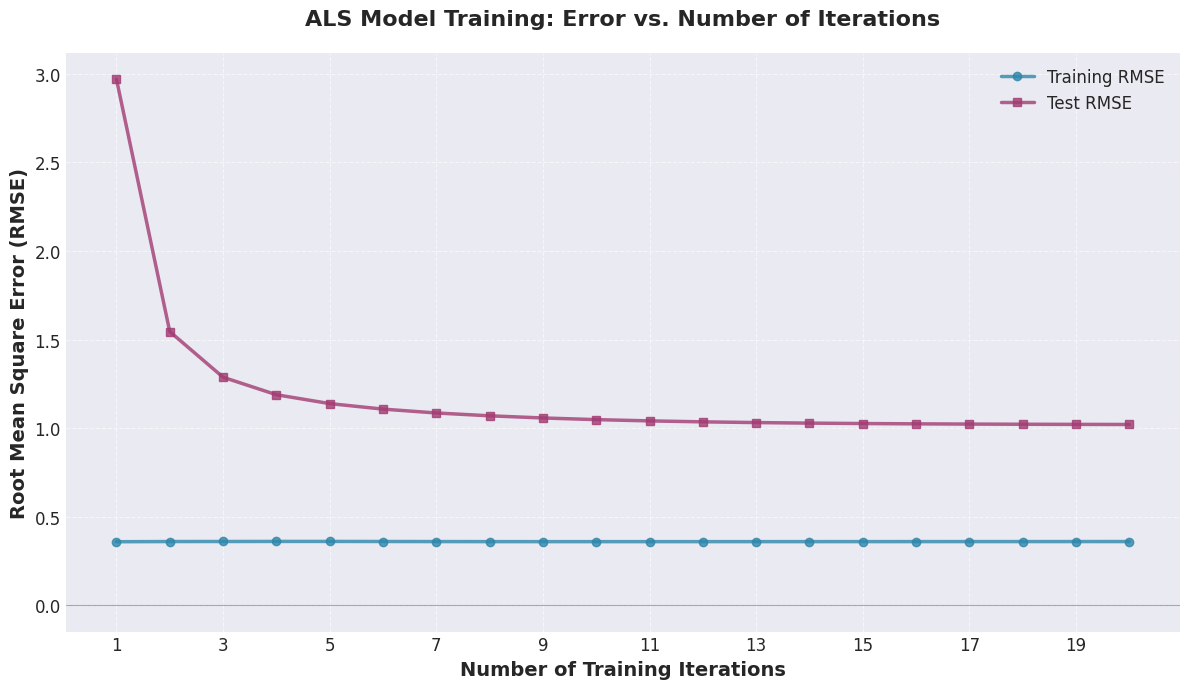


ANALYSIS RESULTS
Optimal number of iterations: 20
Minimum Test RMSE achieved: 1.0205
Final Training RMSE (at iteration 20): 0.3597
Final Test RMSE (at iteration 20): 1.0205

Note: Training RMSE is 0.6608 lower than Test RMSE.
This may indicate some overfitting. Consider:
  - Increasing regularization (regParam)
  - Reducing model complexity (rank)
  - Using early stopping at iteration 20


In [7]:
"""
ALS Training Error Plot Code
============================
Visualize how the RMSE (Root Mean Square Error) decreases during ALS training iterations.

"""

# ============================================================================
# Section 3.5: Training Error Visualization
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Configure plot style for better appearance
plt.style.use('seaborn-v0_8-darkgrid')

# Training parameters
MAX_ITER = 20  # Number of training iterations to test
RANK = 10      # Number of latent factors (from your original model)
REG_PARAM = 0.05  # Regularization parameter (from your original model)

# Lists to store training history
iterations = []
train_rmse_history = []
test_rmse_history = []

print("Training ALS model across multiple iterations...")
print("=" * 60)

# Train models with increasing number of iterations
for n_iter in range(1, MAX_ITER + 1):
    # Create ALS model with current iteration count
    als_iter = ALS(
        rank=RANK,
        maxIter=n_iter,  # Vary the number of iterations
        implicitPrefs=False,
        regParam=REG_PARAM,
        coldStartStrategy='drop',
        nonnegative=False,
        seed=42,
        **header
    )
    
    # Train the model
    model_iter = als_iter.fit(train)
    
    # Generate predictions on training set
    train_predictions = model_iter.transform(train)
    train_eval = SparkRatingEvaluation(
        train, 
        train_predictions,
        col_user=COL_USER,
        col_item=COL_ITEM_ID,
        col_rating=COL_RATING,
        col_prediction="prediction"
    )
    train_rmse = train_eval.rmse()
    
    # Generate predictions on test set
    test_predictions = model_iter.transform(test)
    test_eval = SparkRatingEvaluation(
        test,
        test_predictions,
        col_user=COL_USER,
        col_item=COL_ITEM_ID,
        col_rating=COL_RATING,
        col_prediction="prediction"
    )
    test_rmse = test_eval.rmse()
    
    # Store results
    iterations.append(n_iter)
    train_rmse_history.append(train_rmse)
    test_rmse_history.append(test_rmse)
    
    # Print progress every 5 iterations
    if n_iter % 5 == 0 or n_iter == 1:
        print(f"Iteration {n_iter:2d}: Train RMSE = {train_rmse:.4f}, Test RMSE = {test_rmse:.4f}")

print("=" * 60)
print("Training complete")

# ============================================================================
# Plotting the Error Curves
# ============================================================================

# Create figure with high resolution
fig, ax = plt.subplots(figsize=(12, 7))

# Plot training and test RMSE
ax.plot(iterations, train_rmse_history, 
        marker='o', 
        linewidth=2.5, 
        markersize=6,
        color='#2E86AB',  # Professional blue
        label='Training RMSE',
        alpha=0.8)

ax.plot(iterations, test_rmse_history, 
        marker='s', 
        linewidth=2.5, 
        markersize=6,
        color='#A23B72',  # Professional magenta
        label='Test RMSE',
        alpha=0.8)

# Add grid for better readability
ax.grid(True, linestyle='--', alpha=0.6, linewidth=0.8)

# Set labels with proper font sizes
ax.set_xlabel('Number of Training Iterations', fontsize=14, fontweight='bold')
ax.set_ylabel('Root Mean Square Error (RMSE)', fontsize=14, fontweight='bold')
ax.set_title('ALS Model Training: Error vs. Number of Iterations', 
             fontsize=16, fontweight='bold', pad=20)

# Customize tick labels
ax.tick_params(axis='both', which='major', labelsize=12)

# Add legend with better positioning
ax.legend(loc='upper right', fontsize=12, framealpha=0.9, shadow=True)

# Set x-axis to show integer values only
ax.set_xticks(range(1, MAX_ITER + 1, 2))

# Add horizontal line at y=0 for reference
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)

# Tight layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()

# ============================================================================
# Additional Analysis: Find Optimal Iteration Count
# ============================================================================

# Find the iteration with minimum test RMSE
optimal_iter = iterations[np.argmin(test_rmse_history)]
min_test_rmse = min(test_rmse_history)

print("\n" + "=" * 60)
print("ANALYSIS RESULTS")
print("=" * 60)
print(f"Optimal number of iterations: {optimal_iter}")
print(f"Minimum Test RMSE achieved: {min_test_rmse:.4f}")
print(f"Final Training RMSE (at iteration {MAX_ITER}): {train_rmse_history[-1]:.4f}")
print(f"Final Test RMSE (at iteration {MAX_ITER}): {test_rmse_history[-1]:.4f}")

# Check for overfitting
if train_rmse_history[-1] < test_rmse_history[-1]:
    gap = test_rmse_history[-1] - train_rmse_history[-1]
    print(f"\nNote: Training RMSE is {gap:.4f} lower than Test RMSE.")
    print("This may indicate some overfitting. Consider:")
    print("  - Increasing regularization (regParam)")
    print("  - Reducing model complexity (rank)")
    print("  - Using early stopping at iteration", optimal_iter)
print("=" * 60)


In [8]:
with Timer() as train_time:
    model = als.fit(train)

print("Took {} seconds for training.".format(train_time.interval))

Took 0.8720581904053688 seconds for training.


In [9]:
# with Timer() as test_time:

#     # Get the cross join of all user-item pairs and score them.
#     users = train.select(COL_USER).distinct()
#     items = train.select(COL_ITEM).distinct()
#     user_item = users.crossJoin(items)
#     dfs_pred = model.transform(user_item)

#     # Remove seen items.
#     dfs_pred_exclude_train = dfs_pred.alias("pred").join(
#         train.alias("train"),
#         (dfs_pred[COL_USER] == train[COL_USER]) & (dfs_pred[COL_ITEM] == train[COL_ITEM]),
#         how='outer'
#     )

#     top_all = dfs_pred_exclude_train.filter(dfs_pred_exclude_train[f"train.{COL_RATING}"].isNull()) \
#         .select('pred.' + COL_USER, 'pred.' + COL_ITEM, 'pred.' + "prediction")

#     # In Spark, transformations are lazy evaluation
#     # Use an action to force execute and measure the test time 
#     top_all.cache().count()

# print("Took {} seconds for prediction.".format(test_time.interval))

with Timer() as test_time:
    users = train.select(COL_USER).distinct()

    items = train.select(COL_ITEM_ID).distinct()

    user_item = users.crossJoin(items)
    dfs_pred = model.transform(user_item)

    top_all = dfs_pred.join(
        indexed_data.select(COL_USER, COL_ITEM_ID),
        on=[COL_USER, COL_ITEM_ID],
        how='left_anti'
    )

    # Force execution to measure the time
    top_all.cache().count()

print("Took {} seconds for prediction.".format(test_time.interval))

Took 0.6958581488579512 seconds for prediction.


In [10]:
top_all.show()

+------+----------+----------+
|UserId|ClothingId|prediction|
+------+----------+----------+
|    34|         8| 3.4769917|
|    28|         8| 3.3735826|
|    44|         8|  3.773014|
|    12|         8| 2.7010567|
|     1|         8| 3.0013812|
|    13|         8| 2.6372995|
|    16|         8| 3.2119908|
|    20|         8| 2.6956894|
|    40|         8|  3.215877|
|    48|         8| 3.3291528|
|     5|         8| 3.2664375|
|    19|         8| 3.1566951|
|    41|         8| 2.9791172|
|    15|         8|   3.07675|
|    43|         8| 2.6586683|
|    37|         8| 3.7574487|
|     9|         8| 3.2943156|
|    23|         8|  4.015534|
|     7|         8| 2.3296294|
|    10|         8| 3.2763994|
+------+----------+----------+
only showing top 20 rows


### 5. Evaluation

In [11]:
rank_eval = SparkRankingEvaluation(test, top_all, k = TOP_K, col_user=COL_USER, col_item=COL_ITEM_ID, 
                                    col_rating=COL_RATING, col_prediction="prediction", 
                                    relevancy_method="top_k")

In [12]:
print("Model:\tALS",
      "Top K:\t%d" % rank_eval.k,
      "MAP:\t%f" % rank_eval.map_at_k(),
      "NDCG:\t%f" % rank_eval.ndcg_at_k(),
      "Precision@K:\t%f" % rank_eval.precision_at_k(),
      "Recall@K:\t%f" % rank_eval.recall_at_k(), sep='\n')

Model:	ALS
Top K:	1
MAP:	0.000000
NDCG:	0.000000
Precision@K:	0.000000
Recall@K:	0.000000


### 6. Evaluate Rating Prediction

In [13]:
# Generate predicted ratings.
prediction = model.transform(test)
prediction.cache().show()


+------+-------+-----------------+------+----------+----------+
|UserId|Weather|         Clothing|Rating|ClothingId|prediction|
+------+-------+-----------------+------+----------+----------+
|    31| Cloudy|           Chinos|   4.3|        11| 3.7188847|
|    31|  Snowy|       Sweatshirt|   4.2|         9| 3.8126125|
|    34|  Humid|         Cardigan|   4.5|         0|  4.022632|
|    34|  Rainy|       Sweatshirt|   3.6|         9|  3.950525|
|    34|  Sunny|             Coat|   2.2|         1| 3.0534225|
|    34|  Windy|           Henley|   3.3|        17| 3.1508389|
|    28|  Snowy|Long-sleeve shirt|   3.7|         2| 2.6201563|
|    26|  Rainy|Button-down shirt|   3.3|         6| 3.5715094|
|    26|  Snowy|             Coat|   4.2|         1| 3.2566144|
|    26|  Sunny|           Blazer|   3.4|         5| 2.9152653|
|    26|  Windy|         Cardigan|   2.6|         0| 3.1782107|
|    27|  Sunny|           Henley|   3.4|        17|  3.427043|
|    27|  Windy|         Tank top|   2.4

In [14]:
rating_eval = SparkRatingEvaluation(test, prediction, col_user=COL_USER, col_item=COL_ITEM, 
                                    col_rating=COL_RATING, col_prediction="prediction")

print("Model:\tALS rating prediction",
      "RMSE:\t%f" % rating_eval.rmse(),
      "MAE:\t%f" % rating_eval.mae(),
      "Explained variance:\t%f" % rating_eval.exp_var(),
      "R squared:\t%f" % rating_eval.rsquared(), sep='\n')

Model:	ALS rating prediction
RMSE:	1.025804
MAE:	0.815928
Explained variance:	-0.225434
R squared:	-0.240670


### 7. Top-K Recommendations for All Users

In [15]:
# ============================================================================
# Side-by-Side Comparison: Past Favorites vs. Recommendations
# ============================================================================

import pandas as pd
import pyspark.sql.functions as F

def show_side_by_side_comparison(user_id, n=5):
    """
    Show past favorites and recommendations side by side for comparison
    
    Parameters:
    - user_id: The user ID to analyze
    - n: Number of items to show in each column (default: 5)
    
    Returns:
    - pandas DataFrame with side-by-side comparison
    """
    
    # ═══════════════════════════════════════════════════════════════
    # Get Past Favorites (Top N rated items)
    # ═══════════════════════════════════════════════════════════════
    past_favorites = indexed_data \
        .filter(F.col(COL_USER) == user_id) \
        .select(COL_ITEM, COL_RATING) \
        .orderBy(F.col(COL_RATING).desc()) \
        .limit(n) \
        .withColumnRenamed(COL_ITEM, "Past_Favorites") \
        .withColumnRenamed(COL_RATING, "Past_Rating")
    
    # ═══════════════════════════════════════════════════════════════
    # Get Top N Recommendations (Predicted ratings for unseen items)
    # ═══════════════════════════════════════════════════════════════
    recommendations = top_all \
        .filter(F.col(COL_USER) == user_id) \
        .orderBy(F.col("prediction").desc()) \
        .limit(n)
    
    # Join with clothing names
    clothing_mapping = indexed_data.select(COL_ITEM_ID, COL_ITEM).distinct()
    
    recommendations_with_names = recommendations.join(
        clothing_mapping,
        on=COL_ITEM_ID,
        how='left'
    ).select(COL_ITEM, "prediction") \
     .withColumnRenamed(COL_ITEM, "Recommendations") \
     .withColumnRenamed("prediction", "Predicted_Rating")
    
    # ═══════════════════════════════════════════════════════════════
    # Convert to Pandas for side-by-side display
    # ═══════════════════════════════════════════════════════════════
    past_pd = past_favorites.toPandas()
    rec_pd = recommendations_with_names.toPandas()
    
    # Create side-by-side dataframe
    comparison = pd.concat([past_pd, rec_pd], axis=1)
    
    # Display results
    print(f"\n{'='*80}")
    print(f"USER {user_id} - PAST FAVORITES vs. RECOMMENDATIONS")
    print(f"{'='*80}")
    print(f"\nShowing top {n} items in each category\n")
    print(comparison.to_string(index=False))
    print(f"\n{'='*80}\n")
    
    return comparison


# ============================================================================
# Enhanced Version with Weather Context
# ============================================================================

def show_detailed_side_by_side(user_id, n=5):
    """
    Enhanced version that includes weather information for past favorites
    
    Parameters:
    - user_id: The user ID to analyze
    - n: Number of items to show in each column (default: 5)
    
    Returns:
    - pandas DataFrame with detailed comparison
    """
    
    # Get Past Favorites with Weather
    past_favorites = indexed_data \
        .filter(F.col(COL_USER) == user_id) \
        .select(COL_ITEM, COL_WEATHER, COL_RATING) \
        .orderBy(F.col(COL_RATING).desc()) \
        .limit(n)
    
    # Get Recommendations
    recommendations = top_all \
        .filter(F.col(COL_USER) == user_id) \
        .orderBy(F.col("prediction").desc()) \
        .limit(n)
    
    clothing_mapping = indexed_data.select(COL_ITEM_ID, COL_ITEM).distinct()
    
    recommendations_with_names = recommendations.join(
        clothing_mapping,
        on=COL_ITEM_ID,
        how='left'
    ).select(COL_ITEM, "prediction")
    
    # Convert to Pandas
    past_pd = past_favorites.toPandas()
    rec_pd = recommendations_with_names.toPandas()
    
    # Rename columns for clarity
    past_pd.columns = ['Past_Favorites', 'Weather_Worn', 'Past_Rating']
    rec_pd.columns = ['Recommendations', 'Predicted_Rating']
    
    # Create side-by-side dataframe
    comparison = pd.concat([past_pd, rec_pd], axis=1)
    
    # Add rank numbers
    comparison.insert(0, 'Rank', range(1, len(comparison) + 1))
    
    # Display results
    print(f"\n{'='*90}")
    print(f"USER {user_id} - DETAILED ANALYSIS")
    print(f"{'='*90}")
    print(f"\nTop {n} Past Favorites (Left) vs. Top {n} Recommendations (Right)\n")
    print(comparison.to_string(index=False))
    print(f"\n{'='*90}\n")
    
    # Add insights
    print("📊 INSIGHTS:")
    print(f"   • Average past rating: {past_pd['Past_Rating'].mean():.2f}")
    print(f"   • Average predicted rating: {rec_pd['Predicted_Rating'].mean():.2f}")
    print(f"   • Highest rated past item: {past_pd.iloc[0]['Past_Favorites']} ({past_pd.iloc[0]['Past_Rating']:.2f})")
    print(f"   • Top recommendation: {rec_pd.iloc[0]['Recommendations']} ({rec_pd.iloc[0]['Predicted_Rating']:.2f})")
    print()
    
    return comparison


# ============================================================================
# Multiple Users Comparison
# ============================================================================

def compare_multiple_users(user_ids, n=3):
    """
    Compare recommendations across multiple users
    
    Parameters:
    - user_ids: List of user IDs to compare
    - n: Number of recommendations per user
    
    Returns:
    - Dictionary of DataFrames, one per user
    """
    results = {}
    
    print(f"\n{'='*80}")
    print(f"COMPARING {len(user_ids)} USERS - TOP {n} RECOMMENDATIONS")
    print(f"{'='*80}\n")
    
    for user_id in user_ids:
        print(f"\n--- USER {user_id} ---")
        comparison = show_side_by_side_comparison(user_id, n)
        results[user_id] = comparison
        print()
    
    return results


# ============================================================================
# USAGE EXAMPLES
# ============================================================================

# Example 1: Basic side-by-side for User 1
print("\n" + "▶"*40)
print("EXAMPLE 1: Basic Side-by-Side Comparison")
print("▶"*40)

comparison_user1 = show_side_by_side_comparison(user_id=1, n=5)

# Example 2: Detailed version with weather for User 1
print("\n" + "▶"*40)
print("EXAMPLE 2: Detailed Analysis with Weather Context")
print("▶"*40)

detailed_comparison = show_detailed_side_by_side(user_id=1, n=5)

# Example 3: Compare multiple users
print("\n" + "▶"*40)
print("EXAMPLE 3: Multi-User Comparison")
print("▶"*40)

multi_user_results = compare_multiple_users(user_ids=[1, 2, 5, 10], n=3)

# Example 4: Export to CSV (optional)
print("\n" + "▶"*40)
print("EXAMPLE 4: Export to CSV")
print("▶"*40)

# Save User 1's comparison to CSV
comparison_user1.to_csv('/tmp/user1_recommendations.csv', index=False)
print("✅ Saved to /tmp/user1_recommendations.csv")

# Display the saved data
print("\nSaved data preview:")
print(comparison_user1.head())


▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶
EXAMPLE 1: Basic Side-by-Side Comparison
▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶

USER 1 - PAST FAVORITES vs. RECOMMENDATIONS

Showing top 5 items in each category

   Past_Favorites  Past_Rating Recommendations  Predicted_Rating
           Hoodie          4.4          Chinos          3.951685
           Henley          4.0            Coat          3.492735
Long-sleeve shirt          3.9     Windbreaker          3.357618
Button-down shirt          3.5           Jeans          3.283581
      Track pants          3.4        Cardigan          3.256527



▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶
EXAMPLE 2: Detailed Analysis with Weather Context
▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶

USER 1 - DETAILED ANALYSIS

Top 5 Past Favorites (Left) vs. Top 5 Recommendations (Right)

 Rank    Past_Favorites Weather_Worn  Past_Rating Recommendations  Predicted_Rating
    1            Hoodie        Windy          4.4          Chinos          3.951685
    2  

In [16]:
# cleanup spark instance
spark.stop()